# MA22037 coursework (2025-26)

# Section A

## A1

## A2

## A3

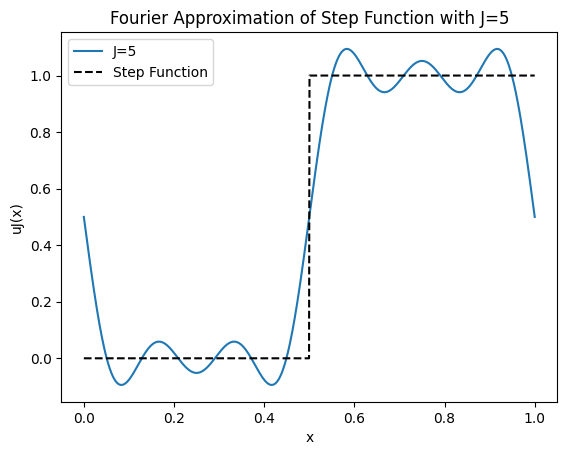

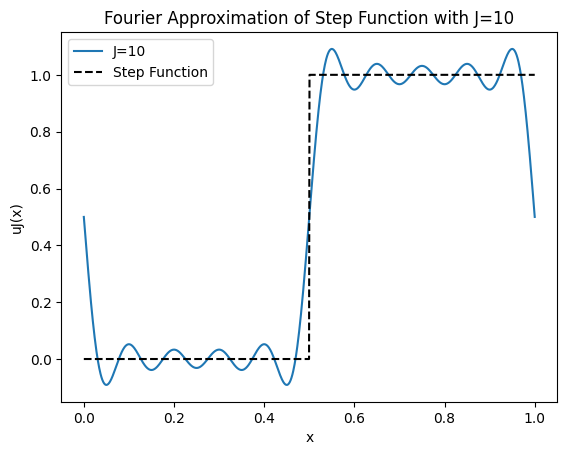

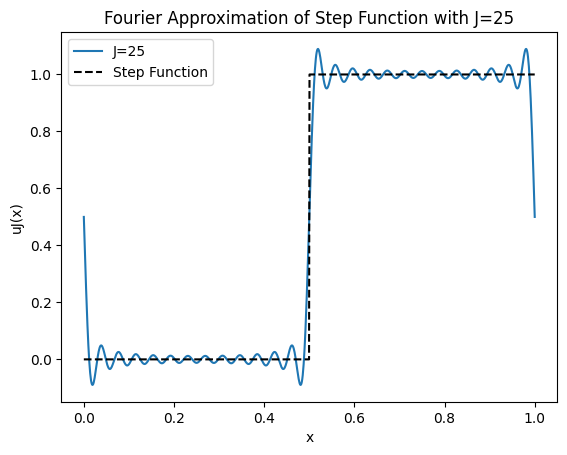

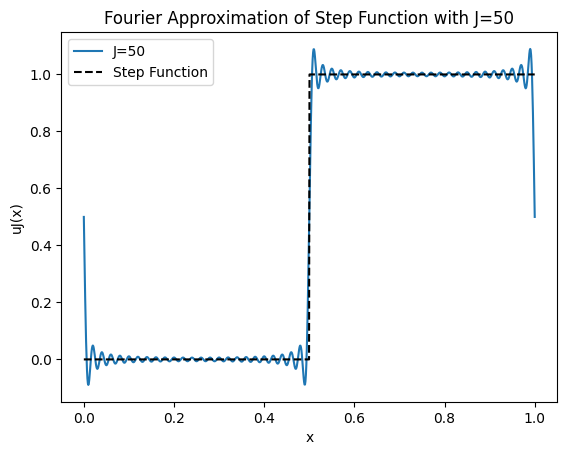

In [13]:
import numpy as np

u_k = lambda k: 1/2 if k == 0 else ((-1/(2j*k*np.pi)) * (1 - np.exp(-1j*k*np.pi)))
step_function = lambda x: 0 if x < 0.5 else 1

def  step_fn(J):
# Fourier approx to step function with 2J +1 terms
    N=1000
    grid=np.linspace(0,1,N)
    # FILL IN to define uJ

    uJ = np.zeros(N, dtype=complex)
    for k in range(-J, J+1):
        uJ += u_k(k) * np.exp(2j * np.pi * k * grid)

    return grid, uJ

import matplotlib.pyplot as plt
#Use plt to plot uJ for J=5,10,25,50

J_values = [5, 10, 25, 50]

for J in J_values:
    grid, uJ = step_fn(J)
    plt.plot(grid, np.real(uJ), label=f'J={J}')
    plt.plot(grid, [step_function(x) for x in grid], 'k--', label='Step Function')
    plt.title(f'Fourier Approximation of Step Function with J={J}')
    plt.xlabel('x')
    plt.ylabel('uJ(x)')
    plt.legend()
    plt.show()


The Gibbs phenomenon is the oscillatory behavior of the Fourier series of a piecewise continuously differentiable periodic function around a jump discontinuity. We see this clearly here at the point where x = 0.5 and y jumps from 0 to 1.

## A4

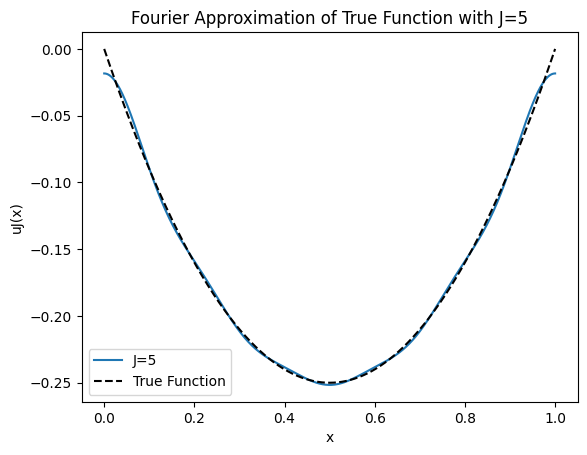

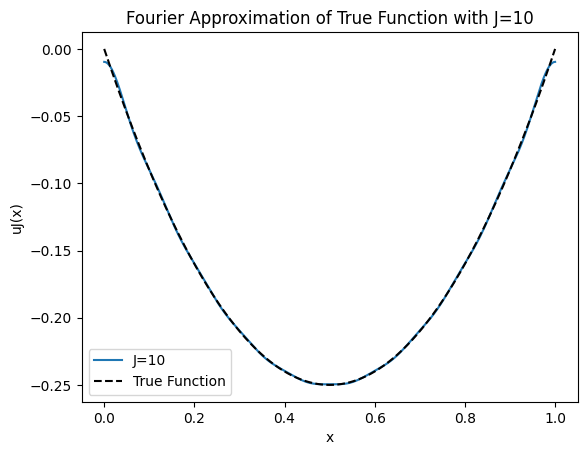

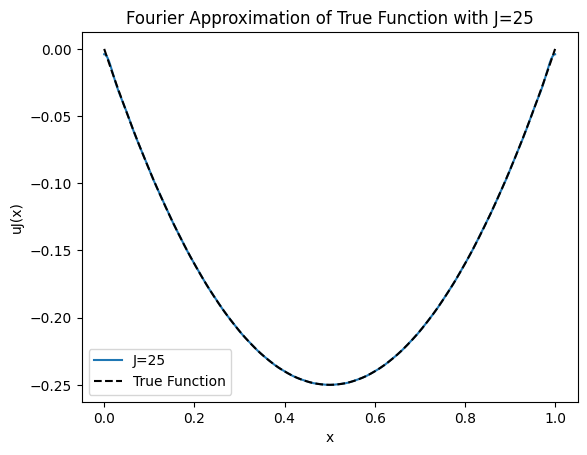

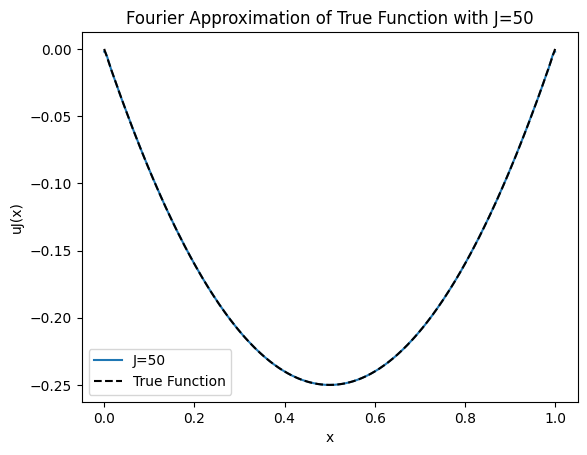

In [17]:

import numpy as np

u_k = lambda k: -1/6 if k == 0 else (1/(2*(np.pi**2)*(k**2)))
true_function = lambda x: x**2 - x

def  step_fn(J):
# Fourier approx to step function with 2J +1 terms
    N=1000
    grid=np.linspace(0,1,N)
    # FILL IN to define uJ

    uJ = np.zeros(N, dtype=complex)
    for k in range(-J, J+1):
        uJ += u_k(k) * np.exp(2j * np.pi * k * grid)

    return grid, uJ

import matplotlib.pyplot as plt
#Use plt to plot uJ for J=5,10,25,50

J_values = [5, 10, 25, 50]

for J in J_values:
    grid, uJ = step_fn(J)
    plt.plot(grid, np.real(uJ), label=f'J={J}')
    plt.plot(grid, [true_function(x) for x in grid], 'k--', label='True Function')
    plt.title(f'Fourier Approximation of True Function with J={J}')
    plt.xlabel('x')
    plt.ylabel('uJ(x)')
    plt.legend()
    plt.show()


## A5

# Section B

## B1

Using the composite trapezium rule defined in the lecture notes,

$$Q_{1,J}^{[a,b]} := h\left(\frac{u(a)}{2} + \sum_{j=1}^{J-1} u(\theta_j) + \frac{u(b)}{2}\right)$$

with $a = 0$, $b = 1$, and $h = \dfrac{1}{J}$

$$Q_{1,J}^{[0,1]} := \frac{1}{J}\left(\frac{u(0)}{2} + \sum_{j=1}^{J-1} u\!\left(\frac{j}{J}\right) + \frac{u(1)}{2}\right)$$

$$\text{Since } u(0)=u(1), \quad \frac{u(0)}{2} + \frac{u(1)}{2} = u(0)$$

$$:= \frac{1}{J}\left(u(0) + \sum_{j=1}^{J-1} u\!\left(\frac{j}{J}\right)\right)$$

Reindexing $\displaystyle\sum_{j=1}^{J-1}$ to $\displaystyle\sum_{j=0}^{J-1}$,

we can absorb $u(0)$ into the sum:

$$\boxed{Q_{1,J}^{[0,1]} := \frac{1}{J}\sum_{j=0}^{J-1} u\!\left(\frac{j}{J}\right)}$$

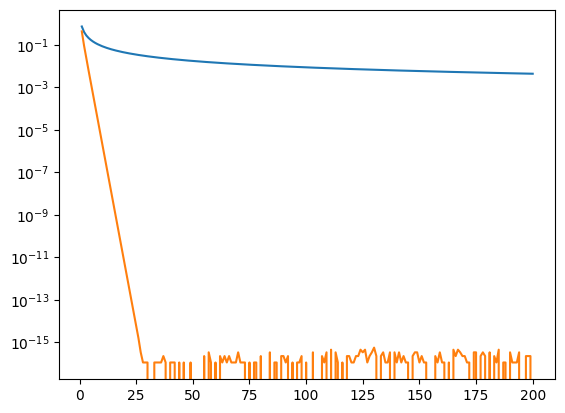

In [39]:
from scipy.integrate import quad

def per_trap(u,J):
    #FILL IN

    I = 0

    for j in range(J):
        I += ((1/J) * u(j/J))

    return I


u_1 = lambda x: np.exp(x)
u_2 = lambda x: 1 / (2 - np.cos(2 * np.pi * x))

J_values = np.arange(1, 201)

for u in [u_1, u_2]:

    abs_errors = []

    for J in J_values:

        I = per_trap(u, J)
        quadval = quad(u, 0, 1)[0]
        absolute_error = abs(I - quadval)
        abs_errors.append(absolute_error)

    plt.semilogy(J_values, abs_errors)




## B2

### Evaluating $T(e^{2\pi k i x})$

$$T(e^{2\pi k i x}) = \frac{1}{J} \sum_{j=0}^{J-1} e^{2\pi k i (j/J)}$$

Let $r = e^{2\pi i (k/J)}$, so:

$$= \frac{1}{J} \sum_{j=0}^{J-1} e^{2\pi i (k/J) j} = \frac{1}{J} \cdot \frac{r^{J} - 1}{r - 1} \quad \text{for } r \neq 1$$

$r = 1$ when $e^{2\pi k i / J} = 1$, which is when $J$ divides $k$.

When $J \mid k$: $r = 1$ for all $j$, and so $\dfrac{1}{J} \cdot J = 1$.

When $J \nmid k$: $\quad 1 - r^{J} = 1 - e^{2\pi k i} = 1 - 1 = 0$

$$\boxed{T(e^{2\pi k i x}) = \begin{cases} 1 & J \text{ divides } k \\ 0 & J \text{ does not divide } k \end{cases}}$$

---

### Evaluating $\displaystyle\int_0^1 e^{2\pi k i x}\,dx$

$$\int_0^1 e^{2\pi k i x}\,dx = \frac{1}{2\pi k i}\left[e^{2\pi k i x}\right]_0^1 = \frac{1}{2\pi k i}\left[1 - 1\right] = 0$$

$$\int_0^1 e^{2\pi k i x}\,dx = \begin{cases} 1 & k = 0 \\ 0 & k \neq 0 \end{cases}$$

---
### Expanding $T(u(x)) - \displaystyle\int_0^1 u(x)\,dx$

Using the Fourier series $u(x) = \displaystyle\sum_{k=-\infty}^{\infty} u_k\, e^{2\pi k i x}$:

$$\frac{1}{J}\sum_{j=0}^{J-1}\sum_{k=-\infty}^{\infty} u_k\, e^{2\pi k i (j/J)}
\;-\;
\int_0^1 \sum_{k=-\infty}^{\infty} u_k\, e^{2\pi k i x}\,dx$$

Swapping order of summation:

$$\frac{1}{J}\sum_{k=-\infty}^{\infty}\sum_{j=0}^{J-1} u_k\, e^{2\pi k i (j/J)}$$

$$= \sum_{k=-\infty}^{\infty} u_k \cdot \frac{1}{J}\sum_{j=0}^{J-1} e^{2\pi k i (j/J)}$$

Applying the result for $T(e^{2\pi k i x})$:

$$\sum_{k=-\infty}^{\infty} u_k \cdot \begin{cases} 1 & J \text{ divides } k \\ 0 & J \text{ does not divide } k \end{cases}$$

Subtracting the integral term (using $\int_0^1 e^{2\pi k i x}\,dx$):

$$-\;\sum_{k=-\infty}^{\infty} u_k \cdot \begin{cases} 1 & k = 0 \\ 0 & k \neq 0 \end{cases}
\;=\; -u_0$$

Combining:

$$\left[\sum_{k=-\infty}^{\infty} u_k \cdot \begin{cases} 1 & J \text{ divides } k \\ 0 & J \text{ does not divide } k \end{cases}\right] - u_0$$

Since $J \mid k \iff k = mJ$ for some integer $m$:

$$= \sum_{m=-\infty}^{\infty} u_{mJ} - u_0$$

$$\boxed{T(u) - \int_0^1 u(x)\,dx \;=\; \sum_{m \neq 0} u_{mJ}}$$

## B3


We saw from **B2** that:

$$T(u) - \int_0^1 u(x)\,dx = \sum_{m \neq 0} u_{mJ}$$

So the error equals the sum of the Fourier coefficients evaluated at multiples of $J$.

**A5** showed that for non-periodic functions $|u_k|$ decays as $\sim 1/|k|$, whilst for periodic and smooth functions it decays as $\sim 1/|k|^3$.

- For $u(x) = e^x$: since $u(0) = 1 \neq e = u(1)$, the function is **not periodic** on $[0,1]$, so its Fourier coefficients decay slowly, leaving a large residual sum at multiples of $J$ — giving **slow convergence**.
- For $u(x) = \frac{1}{2 - \cos(2\pi x)}$: since $u(0) = u(1)$ and the function is infinitely smooth and periodic, its coefficients decay **exponentially fast** — faster than A5's bound even guarantees — making the sum negligibly small for even moderate $J$, giving the steep exponential drop observed in the **B1** semilogy plot.

# Section C

The size of img is (512, 512)


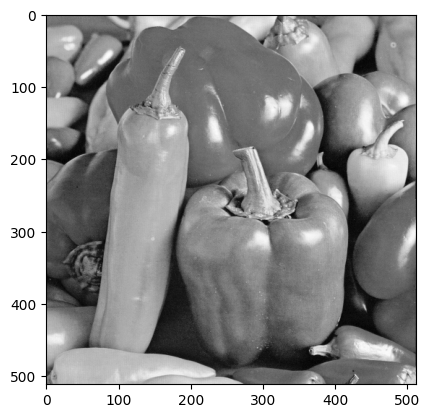

In [2]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread('/Users/willbarnard/Downloads/image_peppers.tiff').mean(axis=2)
imgplot = plt.imshow(img, cmap='gray')
print('The size of img is', img.shape)

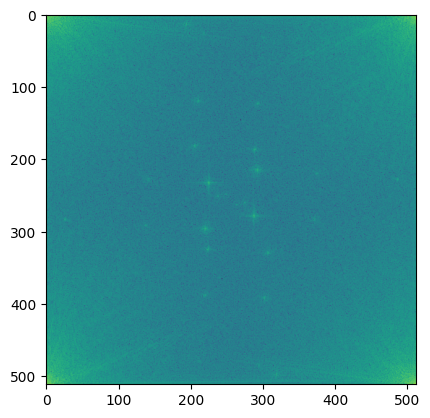

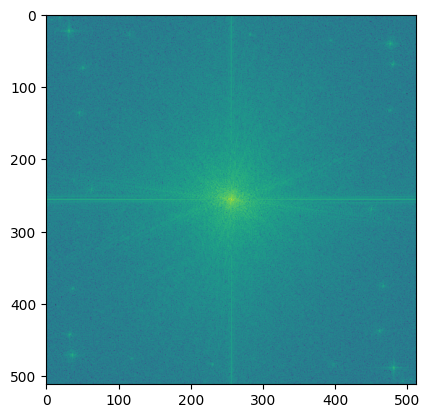

In [3]:
import numpy as np
from numpy.fft import fft2
fftim = fft2(img[:,:])
plt.imshow(np.log(np.abs(fftim))) # visualise absolute values of Fourier coefficients in log
plt.show()

from numpy.fft import fftshift
shiftim = fftshift(fftim)
plt.imshow(np.log(np.abs(shiftim))) # visualise absolute values of Fourier coefficients in lo
plt.show()

## C1

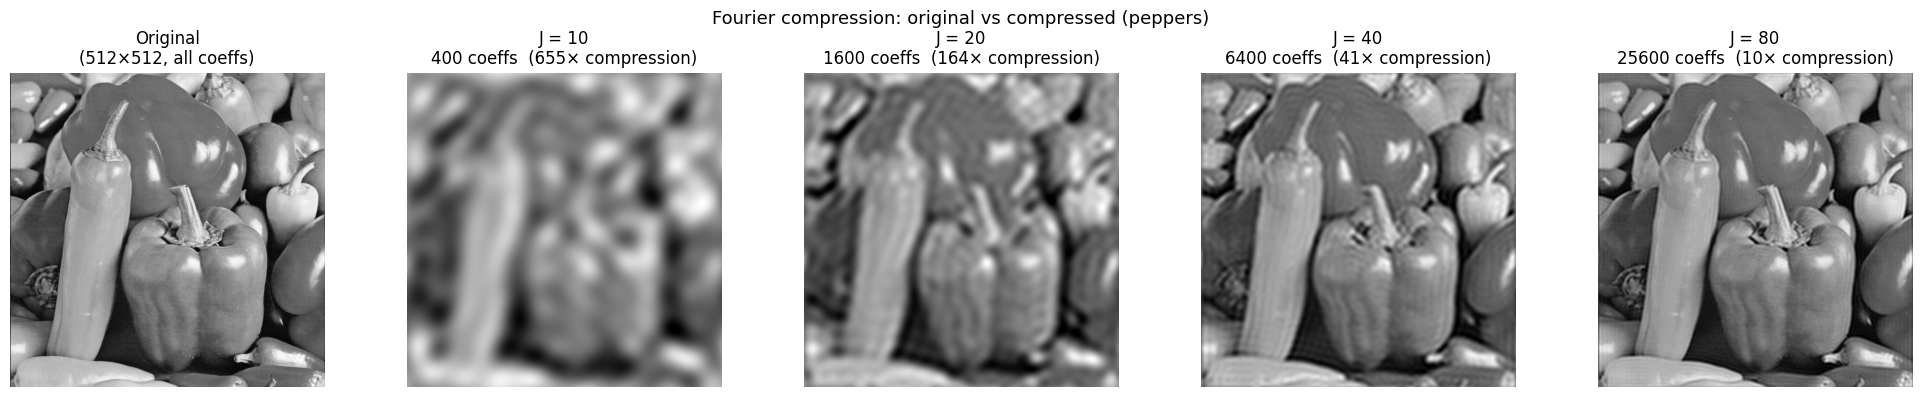

In [37]:
from scipy.fft import fft2, ifft2
import numpy as np
import matplotlib.pyplot as plt

def compress(A, J):
    # assume img is black-and-white or a slice A(:,:,i) of a rgb image
    Ahat = fft2(A)

    n, m = A.shape
    
    #FILL IN
    #Chat = #keep only most important  4J^2 coefficients in Ahat
    Chat = np.zeros_like(Ahat)
    Chat[:J,:J] = Ahat[:J,:J]   
    Chat[:J,m-J:] = Ahat[:J,m-J:]  
    Chat[n-J:,:J] = Ahat[n-J:,:J]  
    Chat[n-J:,m-J:] = Ahat[n-J:,m-J:]   
    
    C = np.real(ifft2(Chat)) #only interested in real part
    return C

J_values = [10, 20, 40, 80]
n, m = img.shape

fig, axes = plt.subplots(1, len(J_values) + 1, figsize=(20, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original\n(512×512, all coeffs)')
axes[0].axis('off')

for ax, J in zip(axes[1:], J_values):
    C = compress(img, J)
    kept  = 4 * J**2
    ratio = (n * m) / kept
    ax.imshow(np.clip(C, 0, 255), cmap='gray')
    ax.set_title(f'J = {J}\n{kept} coeffs  ({ratio:.0f}× compression)')
    ax.axis('off')

plt.suptitle('Fourier compression: original vs compressed (peppers)', fontsize=13)
plt.tight_layout()
plt.show()

**Image Quality**

We can see from the plots above that there is a strong correlation between J and observed image quality, with small J values producing heavily blurred images with minimal fine detail. This mirrors the behaviour in A3, where increasing J improved the Fourier approximation of the step function. Here, a larger J means more coefficients are retained in the reconstruction, producing a more faithful reproduction of the original image. We know that this method retains 4J² coefficients in total, so the amount of information preserved — and hence the image quality — scales as O(J²).

**Artefacts Observed**

By setting all coefficients outside the J×J corners to zero, the images exhibit the same Gibbs phenomenon seen with the step function in A3. Sharp edges (e.g. pepper outlines) appear surrounded by oscillatory halos, which become more pronounced at lower J as a greater proportion of high-frequency coefficients are discarded. Blurring similarly worsens with decreasing J, consistent with the discarded high-frequency coefficients carrying local fine detail, while the retained low-frequency coefficients capture only global structure.

## C2

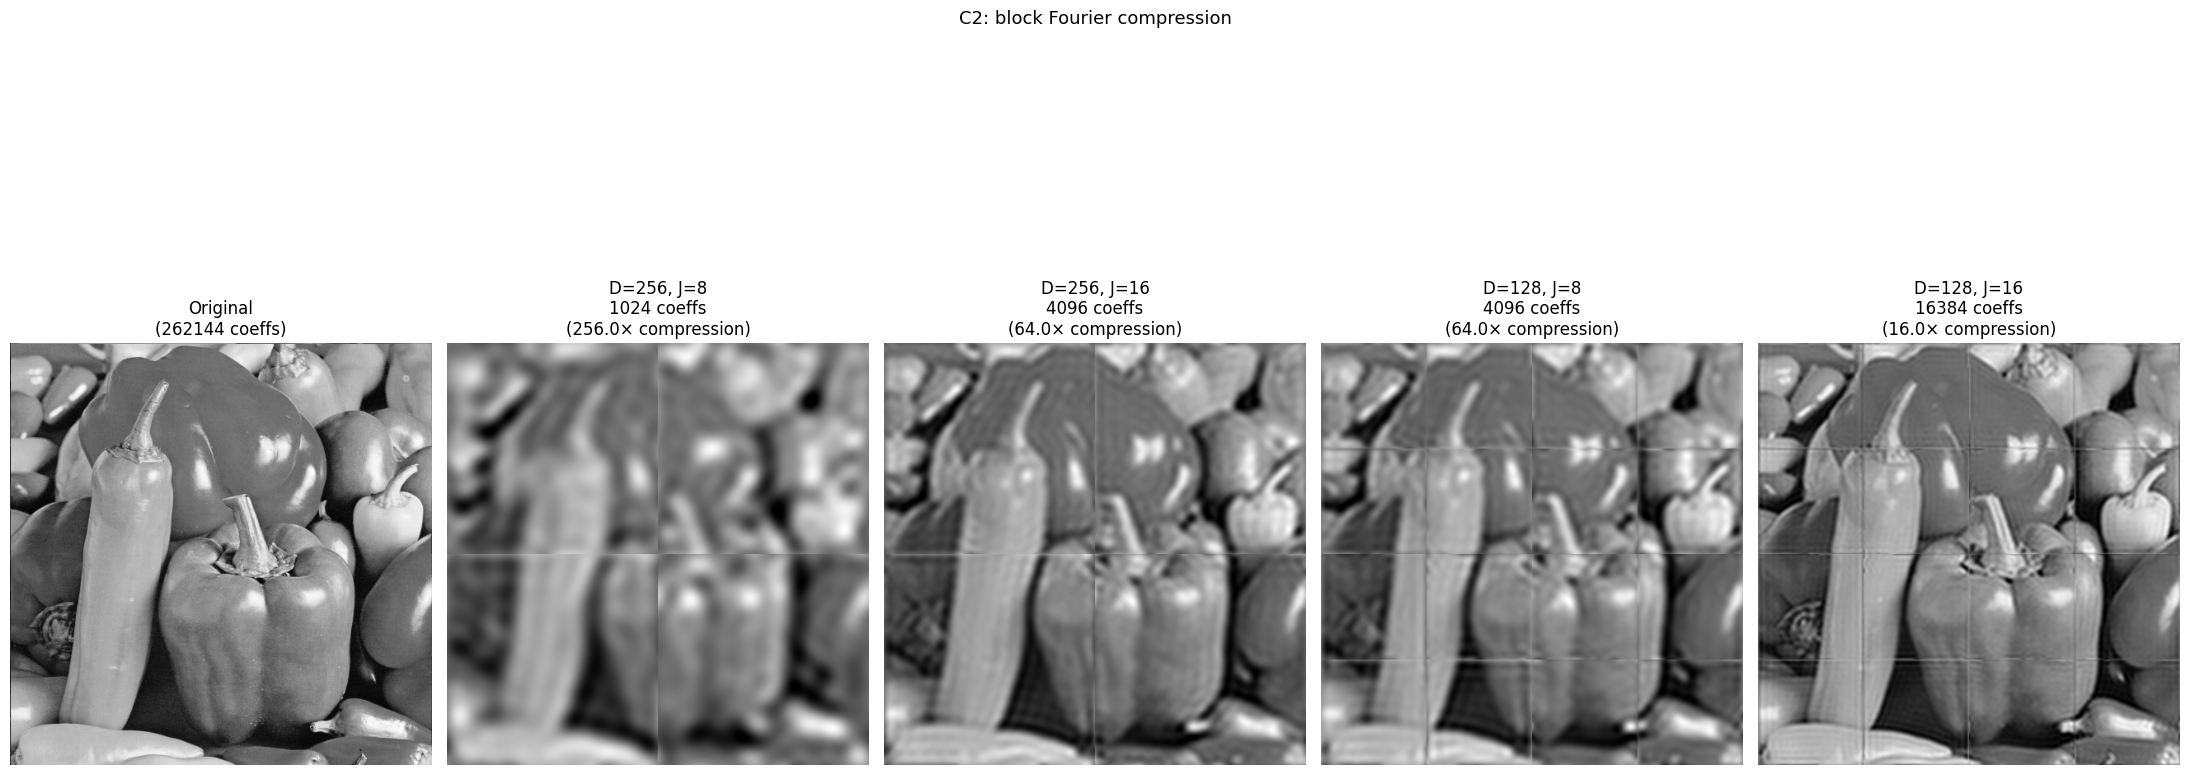

In [35]:
import matplotlib.pyplot as plt
import numpy as np

#inputs: image im
#        J = coefficients in each block
#        D = size of blocks
def compress_v2(im, J, D):
    # FILL IN
    n, m = im.shape
    C = np.zeros_like(im, dtype=float)
    total_coefficients = 0

    for i in range(0, n, D):
        for j in range(0, m, D):
            block = im[i:i+D, j:j+D]
            C[i:i+D, j:j+D] = compress(block, J)
            total_coefficients += 4 * J**2

    return C, total_coefficients


n, m = img.shape

configs = [(256, 8), (256, 16), (128, 8), (128, 16)]

fig, axes = plt.subplots(1, len(configs) + 1, figsize=(22, 11))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original\n(262144 coeffs)')
axes[0].axis('off')

for ax, (D, J) in zip(axes[1:], configs):
    C, total = compress_v2(img, J, D)
    ax.imshow(np.clip(C, 0, 255), cmap='gray')
    ax.set_title(f'D={D}, J={J}\n{total} coeffs\n({n*m/total:.1f}× compression)')
    ax.axis('off')

plt.suptitle('C2: block Fourier compression', fontsize=13)
plt.tight_layout()
plt.show()

**Findings and comparison with C1**

By splitting the image into DxD blocks and compressing each one locally this visually outperforms that of C1 with an apparent increase in image quality for similar compression ratios. This is because each block's content is captured independently, unlike that of a single global transformation. Additionally, Gibbs Phenomenom is localised within each block rather than sperading across the whole image, which makes it less visually disruptive than in C1. However, small D values do introduce visisble block boundaries, as the assumption of independent periodicity between blocks produces the repeated boundary ringing but at every block edge. Small values of J also perform poorly, through the loss of local fine detail across each of the blocks.